In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [3]:
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [10]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [12]:
iris_X = iris.data
iris_y = iris.target
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((135, 4), (15, 4), (135,), (15,))

In [15]:
iris_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 1. 기본적인 DNN (원핫인코딩X)

In [17]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 50)                250       
                                                                 
 dense_4 (Dense)             (None, 30)                1530      
                                                                 
 dense_5 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [18]:
model.compile(loss='sparse_categorical_crossentropy',  # 라벨인코딩만 되어있는 경우 원핫인코딩을 해줌
              optimizer='nadam',
              metrics=['accuracy']
             )
# 학습
earlyStopping = EarlyStopping(patience=50)
hist = model.fit(train_X, train_y,
                epochs=500,
                validation_split=0.2,
                verbose=1,
                callbacks=[earlyStopping])

Epoch 1/500
4/4 [==============================] - 1s 48ms/step - loss: 1.2823 - accuracy: 0.3611 - val_loss: 1.2285 - val_accuracy: 0.2222
Epoch 2/500
4/4 [==============================] - 0s 11ms/step - loss: 1.1610 - accuracy: 0.3611 - val_loss: 1.1166 - val_accuracy: 0.2222
Epoch 3/500
4/4 [==============================] - 0s 11ms/step - loss: 1.0788 - accuracy: 0.3426 - val_loss: 1.0226 - val_accuracy: 0.1852
Epoch 4/500
4/4 [==============================] - 0s 13ms/step - loss: 1.0124 - accuracy: 0.1944 - val_loss: 0.9641 - val_accuracy: 0.2963
Epoch 5/500
4/4 [==============================] - 0s 11ms/step - loss: 0.9661 - accuracy: 0.2500 - val_loss: 0.9258 - val_accuracy: 0.3704
Epoch 6/500
4/4 [==============================] - 0s 11ms/step - loss: 0.9233 - accuracy: 0.4074 - val_loss: 0.8983 - val_accuracy: 0.5926
Epoch 7/500
4/4 [==============================] - 0s 11ms/step - loss: 0.8903 - accuracy: 0.7222 - val_loss: 0.8700 - val_accuracy: 0.5926
Epoch 8/500
4/4 [===

4/4 [==============================] - 0s 13ms/step - loss: 0.2340 - accuracy: 0.9815 - val_loss: 0.2665 - val_accuracy: 0.9630
Epoch 60/500
4/4 [==============================] - 0s 12ms/step - loss: 0.2301 - accuracy: 0.9815 - val_loss: 0.2714 - val_accuracy: 0.9630
Epoch 61/500
4/4 [==============================] - 0s 10ms/step - loss: 0.2321 - accuracy: 0.9815 - val_loss: 0.2768 - val_accuracy: 0.8889
Epoch 62/500
4/4 [==============================] - 0s 11ms/step - loss: 0.2295 - accuracy: 0.9722 - val_loss: 0.2538 - val_accuracy: 0.9630
Epoch 63/500
4/4 [==============================] - 0s 10ms/step - loss: 0.2171 - accuracy: 0.9815 - val_loss: 0.2573 - val_accuracy: 0.9630
Epoch 64/500
4/4 [==============================] - 0s 11ms/step - loss: 0.2144 - accuracy: 0.9907 - val_loss: 0.2597 - val_accuracy: 0.9259
Epoch 65/500
4/4 [==============================] - 0s 12ms/step - loss: 0.2103 - accuracy: 0.9815 - val_loss: 0.2627 - val_accuracy: 0.8889
Epoch 66/500
4/4 [========

4/4 [==============================] - 0s 11ms/step - loss: 0.1042 - accuracy: 0.9815 - val_loss: 0.1480 - val_accuracy: 0.9630
Epoch 118/500
4/4 [==============================] - 0s 11ms/step - loss: 0.1060 - accuracy: 0.9722 - val_loss: 0.1528 - val_accuracy: 0.9630
Epoch 119/500
4/4 [==============================] - 0s 13ms/step - loss: 0.1038 - accuracy: 0.9907 - val_loss: 0.1744 - val_accuracy: 0.9259
Epoch 120/500
4/4 [==============================] - 0s 14ms/step - loss: 0.1252 - accuracy: 0.9444 - val_loss: 0.1470 - val_accuracy: 0.9630
Epoch 121/500
4/4 [==============================] - 0s 12ms/step - loss: 0.1005 - accuracy: 0.9907 - val_loss: 0.1545 - val_accuracy: 0.9630
Epoch 122/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0980 - accuracy: 0.9907 - val_loss: 0.1427 - val_accuracy: 0.9630
Epoch 123/500
4/4 [==============================] - 0s 11ms/step - loss: 0.1000 - accuracy: 0.9815 - val_loss: 0.1522 - val_accuracy: 0.9630
Epoch 124/500
4/4 [=

Epoch 175/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0773 - accuracy: 0.9815 - val_loss: 0.1144 - val_accuracy: 0.9630
Epoch 176/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0771 - accuracy: 0.9815 - val_loss: 0.1206 - val_accuracy: 0.9630
Epoch 177/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0745 - accuracy: 0.9907 - val_loss: 0.1138 - val_accuracy: 0.9630
Epoch 178/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0736 - accuracy: 0.9907 - val_loss: 0.1200 - val_accuracy: 0.9630
Epoch 179/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0734 - accuracy: 0.9907 - val_loss: 0.1269 - val_accuracy: 0.9259
Epoch 180/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0786 - accuracy: 0.9815 - val_loss: 0.1117 - val_accuracy: 0.9630
Epoch 181/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0741 - accuracy: 0.9907 - val_loss: 0.1140 - val_accuracy: 0.9630
Epoch 

Epoch 233/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0680 - accuracy: 0.9907 - val_loss: 0.0981 - val_accuracy: 0.9630
Epoch 234/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0647 - accuracy: 0.9907 - val_loss: 0.1029 - val_accuracy: 0.9630
Epoch 235/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0677 - accuracy: 0.9815 - val_loss: 0.0965 - val_accuracy: 0.9630
Epoch 236/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0659 - accuracy: 0.9907 - val_loss: 0.0988 - val_accuracy: 0.9630
Epoch 237/500
4/4 [==============================] - 0s 19ms/step - loss: 0.0702 - accuracy: 0.9815 - val_loss: 0.1004 - val_accuracy: 0.9630
Epoch 238/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0726 - accuracy: 0.9722 - val_loss: 0.0973 - val_accuracy: 0.9630
Epoch 239/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0654 - accuracy: 0.9907 - val_loss: 0.1318 - val_accuracy: 0.9259
Epoch 

Epoch 291/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0621 - accuracy: 0.9907 - val_loss: 0.0905 - val_accuracy: 0.9630
Epoch 292/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0619 - accuracy: 0.9907 - val_loss: 0.0884 - val_accuracy: 0.9630
Epoch 293/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0682 - accuracy: 0.9907 - val_loss: 0.0883 - val_accuracy: 0.9630
Epoch 294/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0657 - accuracy: 0.9722 - val_loss: 0.1109 - val_accuracy: 0.9630
Epoch 295/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0632 - accuracy: 0.9722 - val_loss: 0.0887 - val_accuracy: 0.9630
Epoch 296/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0642 - accuracy: 0.9815 - val_loss: 0.0918 - val_accuracy: 0.9630
Epoch 297/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0655 - accuracy: 0.9815 - val_loss: 0.0942 - val_accuracy: 0.9630
Epoch 

Epoch 349/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0661 - accuracy: 0.9815 - val_loss: 0.0835 - val_accuracy: 0.9630
Epoch 350/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0598 - accuracy: 0.9907 - val_loss: 0.0859 - val_accuracy: 0.9630
Epoch 351/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0580 - accuracy: 0.9907 - val_loss: 0.0846 - val_accuracy: 0.9630
Epoch 352/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0582 - accuracy: 0.9907 - val_loss: 0.1256 - val_accuracy: 0.9259
Epoch 353/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0666 - accuracy: 0.9722 - val_loss: 0.0907 - val_accuracy: 0.9630
Epoch 354/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0623 - accuracy: 0.9815 - val_loss: 0.1627 - val_accuracy: 0.8889
Epoch 355/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0753 - accuracy: 0.9630 - val_loss: 0.1264 - val_accuracy: 0.9259
Epoch 

Epoch 407/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0570 - accuracy: 0.9907 - val_loss: 0.0814 - val_accuracy: 0.9630
Epoch 408/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0566 - accuracy: 0.9815 - val_loss: 0.0802 - val_accuracy: 0.9630
Epoch 409/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0597 - accuracy: 0.9907 - val_loss: 0.0832 - val_accuracy: 0.9630
Epoch 410/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0564 - accuracy: 0.9907 - val_loss: 0.0879 - val_accuracy: 0.9630
Epoch 411/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0576 - accuracy: 0.9815 - val_loss: 0.0826 - val_accuracy: 0.9630
Epoch 412/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0585 - accuracy: 0.9815 - val_loss: 0.0804 - val_accuracy: 0.9630
Epoch 413/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0596 - accuracy: 0.9907 - val_loss: 0.0804 - val_accuracy: 0.9630
Epoch 

Epoch 465/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0572 - accuracy: 0.9907 - val_loss: 0.1109 - val_accuracy: 0.9630
Epoch 466/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0583 - accuracy: 0.9815 - val_loss: 0.1331 - val_accuracy: 0.9259
Epoch 467/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0638 - accuracy: 0.9722 - val_loss: 0.0856 - val_accuracy: 0.9630
Epoch 468/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0566 - accuracy: 0.9815 - val_loss: 0.0889 - val_accuracy: 0.9630
Epoch 469/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0556 - accuracy: 0.9815 - val_loss: 0.0787 - val_accuracy: 0.9630
Epoch 470/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0594 - accuracy: 0.9907 - val_loss: 0.0783 - val_accuracy: 0.9630
Epoch 471/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0588 - accuracy: 0.9907 - val_loss: 0.0781 - val_accuracy: 0.9630
Epoch 

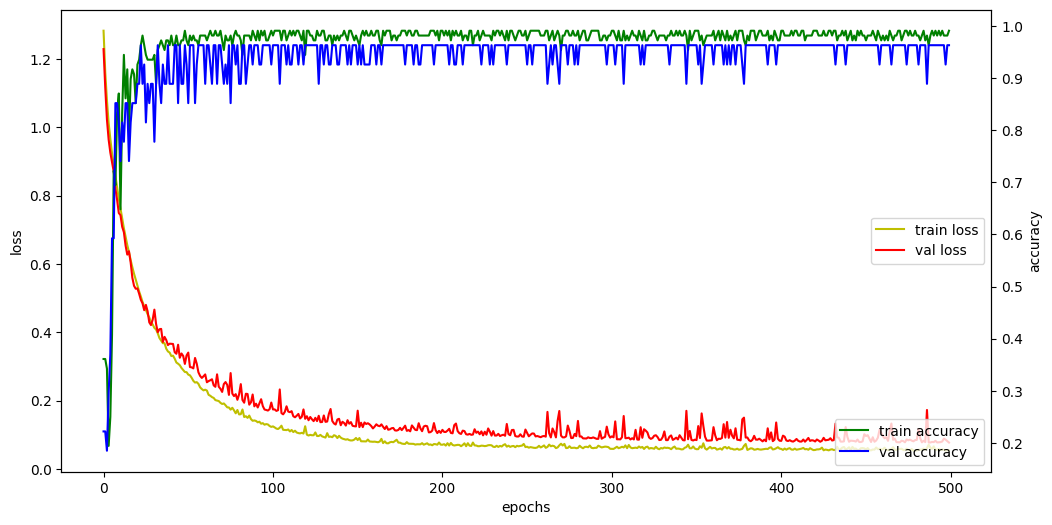

In [19]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()



# 2. sklearn 이용
- 원핫인코딩을 하지 않고, 라벨인코딩까지만 해야 작동
- numpy 배열로 이뤄져있어야함

In [20]:
from sklearn.neural_network import MLPClassifier
# 머신러닝 3장 교안 43p
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                     activation='relu',
                     solver='adam',
                     alpha=0.0001, # 과적합 방지 강도
                     batch_size=40,
                     max_iter=1000, # epochs
                     early_stopping=True, # 조기 종료 활성화
                     n_iter_no_change=50, # patience
                     warm_start=False,
                     validation_fraction=0.1 # 검증셋 비율
                     )

In [21]:
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [26]:
# 모델 평가 : accuracy(test_X, test_y), recall, precision(test_y, y_hat)
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
accuracy = mlp_model.score(test_X,test_y)
y_hat = mlp_model.predict(test_X)
recall = recall_score(test_y, y_hat, average='weighted')
precision = precision_score(test_y, y_hat, average='weighted')
f1_score = f1_score(test_y, y_hat, average='weighted')


print('정확도 :', accuracy)
print('재현율 :', recall)
print('정밀도 :', precision)
print('교차표\n :', pd.crosstab(test_y, y_hat,
                            rownames=['실제'],
                            colnames=['예측']))

정확도 : 0.9333333333333333
재현율 : 0.9333333333333333
정밀도 : 0.9444444444444445
교차표
 : 예측  0  1  2
실제         
0   5  0  0
1   0  5  0
2   0  1  4


# 3. 클래스를 이용

In [27]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
        
# 모델 구성
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(50, activation=activation))
#         model.add(Dense(30, activation=activation))
#         model.add(Dense(3, activation='softmax'))
# 위를 아래처럼 만들수 있다
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax')
        ])
    #모델 학습 설정
        model.compile(loss = 'sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        return model

In [30]:
model = DNNClassifier.build(input_dim=4, activation='relu')
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 50)                250       
                                                                 
 dense_10 (Dense)            (None, 30)                1530      
                                                                 
 dense_11 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [31]:
%%time
hist = model.fit(train_X, train_y,
                epochs=500,
                validation_split=0.2,
                verbose=1)

Epoch 1/500
4/4 [==============================] - 0s 49ms/step - loss: 1.3534 - accuracy: 0.3056 - val_loss: 1.0446 - val_accuracy: 0.4444
Epoch 2/500
4/4 [==============================] - 0s 11ms/step - loss: 1.1047 - accuracy: 0.3056 - val_loss: 0.9662 - val_accuracy: 0.4444
Epoch 3/500
4/4 [==============================] - 0s 11ms/step - loss: 0.9892 - accuracy: 0.3981 - val_loss: 0.9247 - val_accuracy: 0.8148
Epoch 4/500
4/4 [==============================] - 0s 12ms/step - loss: 0.9120 - accuracy: 0.8148 - val_loss: 0.8888 - val_accuracy: 0.5926
Epoch 5/500
4/4 [==============================] - 0s 12ms/step - loss: 0.8575 - accuracy: 0.7130 - val_loss: 0.8542 - val_accuracy: 0.5926
Epoch 6/500
4/4 [==============================] - 0s 18ms/step - loss: 0.8195 - accuracy: 0.7130 - val_loss: 0.8160 - val_accuracy: 0.5926
Epoch 7/500
4/4 [==============================] - 0s 12ms/step - loss: 0.7820 - accuracy: 0.7593 - val_loss: 0.7694 - val_accuracy: 0.7407
Epoch 8/500
4/4 [===

4/4 [==============================] - 0s 12ms/step - loss: 0.1817 - accuracy: 0.9722 - val_loss: 0.2278 - val_accuracy: 0.9630
Epoch 60/500
4/4 [==============================] - 0s 12ms/step - loss: 0.1787 - accuracy: 0.9815 - val_loss: 0.2329 - val_accuracy: 1.0000
Epoch 61/500
4/4 [==============================] - 0s 10ms/step - loss: 0.1766 - accuracy: 0.9815 - val_loss: 0.2264 - val_accuracy: 1.0000
Epoch 62/500
4/4 [==============================] - 0s 11ms/step - loss: 0.1719 - accuracy: 0.9907 - val_loss: 0.2176 - val_accuracy: 0.9630
Epoch 63/500
4/4 [==============================] - 0s 11ms/step - loss: 0.1666 - accuracy: 0.9815 - val_loss: 0.2099 - val_accuracy: 0.9630
Epoch 64/500
4/4 [==============================] - 0s 10ms/step - loss: 0.1640 - accuracy: 0.9815 - val_loss: 0.2043 - val_accuracy: 0.9630
Epoch 65/500
4/4 [==============================] - 0s 12ms/step - loss: 0.1610 - accuracy: 0.9815 - val_loss: 0.2080 - val_accuracy: 0.9630
Epoch 66/500
4/4 [========

4/4 [==============================] - 0s 11ms/step - loss: 0.0868 - accuracy: 0.9907 - val_loss: 0.1350 - val_accuracy: 1.0000
Epoch 118/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0907 - accuracy: 0.9815 - val_loss: 0.1364 - val_accuracy: 1.0000
Epoch 119/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0861 - accuracy: 0.9722 - val_loss: 0.1202 - val_accuracy: 0.9630
Epoch 120/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0901 - accuracy: 0.9815 - val_loss: 0.1184 - val_accuracy: 0.9630
Epoch 121/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0897 - accuracy: 0.9815 - val_loss: 0.1242 - val_accuracy: 0.9630
Epoch 122/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0846 - accuracy: 0.9907 - val_loss: 0.1240 - val_accuracy: 0.9630
Epoch 123/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0845 - accuracy: 0.9907 - val_loss: 0.1214 - val_accuracy: 0.9630
Epoch 124/500
4/4 [=

Epoch 175/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0692 - accuracy: 0.9815 - val_loss: 0.0957 - val_accuracy: 0.9630
Epoch 176/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0710 - accuracy: 0.9815 - val_loss: 0.0954 - val_accuracy: 0.9630
Epoch 177/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0713 - accuracy: 0.9815 - val_loss: 0.1056 - val_accuracy: 0.9630
Epoch 178/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0683 - accuracy: 0.9815 - val_loss: 0.1114 - val_accuracy: 0.9630
Epoch 179/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0688 - accuracy: 0.9815 - val_loss: 0.1039 - val_accuracy: 0.9630
Epoch 180/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0669 - accuracy: 0.9907 - val_loss: 0.0982 - val_accuracy: 0.9630
Epoch 181/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0675 - accuracy: 0.9907 - val_loss: 0.0964 - val_accuracy: 0.9630
Epoch 

Epoch 233/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0629 - accuracy: 0.9815 - val_loss: 0.1001 - val_accuracy: 0.9630
Epoch 234/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0613 - accuracy: 0.9815 - val_loss: 0.0904 - val_accuracy: 0.9630
Epoch 235/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0663 - accuracy: 0.9907 - val_loss: 0.0856 - val_accuracy: 0.9630
Epoch 236/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0644 - accuracy: 0.9815 - val_loss: 0.0875 - val_accuracy: 0.9630
Epoch 237/500
4/4 [==============================] - 0s 10ms/step - loss: 0.0615 - accuracy: 0.9907 - val_loss: 0.0958 - val_accuracy: 0.9630
Epoch 238/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0638 - accuracy: 0.9815 - val_loss: 0.0943 - val_accuracy: 0.9630
Epoch 239/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0725 - accuracy: 0.9815 - val_loss: 0.0871 - val_accuracy: 0.9630
Epoch 

Epoch 291/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0580 - accuracy: 0.9815 - val_loss: 0.0929 - val_accuracy: 0.9630
Epoch 292/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0606 - accuracy: 0.9815 - val_loss: 0.1072 - val_accuracy: 0.9630
Epoch 293/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0612 - accuracy: 0.9722 - val_loss: 0.0851 - val_accuracy: 0.9630
Epoch 294/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0575 - accuracy: 0.9907 - val_loss: 0.0837 - val_accuracy: 0.9630
Epoch 295/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0601 - accuracy: 0.9907 - val_loss: 0.0843 - val_accuracy: 0.9630
Epoch 296/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0635 - accuracy: 0.9815 - val_loss: 0.1086 - val_accuracy: 0.9630
Epoch 297/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0620 - accuracy: 0.9722 - val_loss: 0.0976 - val_accuracy: 0.9630
Epoch 

Epoch 349/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0558 - accuracy: 0.9907 - val_loss: 0.0849 - val_accuracy: 0.9630
Epoch 350/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0549 - accuracy: 0.9815 - val_loss: 0.0902 - val_accuracy: 0.9630
Epoch 351/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0569 - accuracy: 0.9815 - val_loss: 0.0962 - val_accuracy: 0.9630
Epoch 352/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0561 - accuracy: 0.9815 - val_loss: 0.0917 - val_accuracy: 0.9630
Epoch 353/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0560 - accuracy: 0.9815 - val_loss: 0.0858 - val_accuracy: 0.9630
Epoch 354/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0565 - accuracy: 0.9907 - val_loss: 0.0803 - val_accuracy: 0.9630
Epoch 355/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0557 - accuracy: 0.9815 - val_loss: 0.0913 - val_accuracy: 0.9630
Epoch 

Epoch 407/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0541 - accuracy: 0.9815 - val_loss: 0.0859 - val_accuracy: 0.9630
Epoch 408/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0568 - accuracy: 0.9722 - val_loss: 0.0947 - val_accuracy: 0.9630
Epoch 409/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0555 - accuracy: 0.9907 - val_loss: 0.0774 - val_accuracy: 0.9630
Epoch 410/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0544 - accuracy: 0.9907 - val_loss: 0.0789 - val_accuracy: 0.9630
Epoch 411/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0552 - accuracy: 0.9907 - val_loss: 0.0851 - val_accuracy: 0.9259
Epoch 412/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0546 - accuracy: 0.9815 - val_loss: 0.0788 - val_accuracy: 0.9630
Epoch 413/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0541 - accuracy: 0.9907 - val_loss: 0.0811 - val_accuracy: 0.9630
Epoch 

Epoch 465/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0560 - accuracy: 0.9907 - val_loss: 0.0834 - val_accuracy: 0.9259
Epoch 466/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0554 - accuracy: 0.9907 - val_loss: 0.0767 - val_accuracy: 0.9630
Epoch 467/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0533 - accuracy: 0.9815 - val_loss: 0.0890 - val_accuracy: 0.9630
Epoch 468/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0527 - accuracy: 0.9815 - val_loss: 0.0851 - val_accuracy: 0.9630
Epoch 469/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0521 - accuracy: 0.9815 - val_loss: 0.0783 - val_accuracy: 0.9630
Epoch 470/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0543 - accuracy: 0.9907 - val_loss: 0.0749 - val_accuracy: 0.9630
Epoch 471/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0564 - accuracy: 0.9907 - val_loss: 0.0792 - val_accuracy: 0.9630
Epoch 

In [32]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 23ms/step - loss: 0.0337 - accuracy: 1.0000


(0.03372543305158615, 1.0)

# 4. 함수형 API 이용하기
- 병렬처리
- 레지듀얼블록(Residual block) : 모델의 성능을 높이려고(자연어처리, 이미지처리)

In [34]:
import sys
import os
import numpy as np
from tensorflow.keras import Model # 모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Input, add, concatenate # add : 레지듀얼블록, concatenate : 병렬처리
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split  # 데이터 분리
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [35]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(dense1)
dense3 = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=dense3) 
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_15 (Dense)            (None, 50)                250       
                                                                 
 dense_16 (Dense)            (None, 30)                1530      
                                                                 
 dense_17 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [37]:
model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
hist = model.fit(train_X, train_y, epochs=100, validation_split=0.2)

Epoch 1/100
4/4 [==============================] - 0s 48ms/step - loss: 0.0848 - accuracy: 0.9722 - val_loss: 0.0849 - val_accuracy: 0.9630
Epoch 2/100
4/4 [==============================] - 0s 12ms/step - loss: 0.0647 - accuracy: 0.9907 - val_loss: 0.0949 - val_accuracy: 0.9630
Epoch 3/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0628 - accuracy: 0.9722 - val_loss: 0.1325 - val_accuracy: 0.9259
Epoch 4/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0652 - accuracy: 0.9722 - val_loss: 0.0975 - val_accuracy: 0.9630
Epoch 5/100
4/4 [==============================] - 0s 12ms/step - loss: 0.0573 - accuracy: 0.9815 - val_loss: 0.0785 - val_accuracy: 0.9630
Epoch 6/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0564 - accuracy: 0.9907 - val_loss: 0.0777 - val_accuracy: 0.9630
Epoch 7/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0579 - accuracy: 0.9815 - val_loss: 0.0773 - val_accuracy: 0.9630
Epoch 8/100
4/4 [===

4/4 [==============================] - 0s 11ms/step - loss: 0.0546 - accuracy: 0.9907 - val_loss: 0.0793 - val_accuracy: 0.9630
Epoch 60/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0535 - accuracy: 0.9815 - val_loss: 0.0843 - val_accuracy: 0.9630
Epoch 61/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0551 - accuracy: 0.9815 - val_loss: 0.0841 - val_accuracy: 0.9630
Epoch 62/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0532 - accuracy: 0.9815 - val_loss: 0.0761 - val_accuracy: 0.9630
Epoch 63/100
4/4 [==============================] - 0s 11ms/step - loss: 0.0559 - accuracy: 0.9907 - val_loss: 0.0743 - val_accuracy: 0.9630
Epoch 64/100
4/4 [==============================] - 0s 12ms/step - loss: 0.0555 - accuracy: 0.9907 - val_loss: 0.0758 - val_accuracy: 0.9630
Epoch 65/100
4/4 [==============================] - 0s 12ms/step - loss: 0.0571 - accuracy: 0.9815 - val_loss: 0.0858 - val_accuracy: 0.9630
Epoch 66/100
4/4 [========

In [38]:
# 병렬처리
# 4 -> 160(50, 80, 30로 병렬처리) -> 32 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(input_)
dense3 = Dense(units=80, activation='relu')(input_)
X = concatenate([dense1, dense2, dense3])
# 직렬처리 X = Dense(units=160, activation='relu')(input_)
dense4 = Dense(units=32, activation='relu')(X)
output = Dense(units=3, activation='softmax')(dense4)

model = Model(inputs=input_, outputs=output) 
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_18 (Dense)               (None, 50)           250         ['input_7[0][0]']                
                                                                                                  
 dense_19 (Dense)               (None, 30)           150         ['input_7[0][0]']                
                                                                                                  
 dense_20 (Dense)               (None, 80)           400         ['input_7[0][0]']                
                                                                                            

In [39]:
%%time
model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
hist = model.fit(train_X, train_y, epochs=100, validation_split=0.2, verbose=0)

CPU times: total: 4.58 s
Wall time: 3.57 s


In [40]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 23ms/step - loss: 0.0862 - accuracy: 0.9333


[0.08618003875017166, 0.9333333373069763]

In [41]:
# 레지듀얼블록(Residual Block) : 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을때
# 4 > 50 > 50 > (레지듀얼) > 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=50, activation='relu')(dense1)
dense3 = add([dense1, dense2]) # 요소별합
output = Dense(units=3, activation='softmax')(dense3)

model = Model(inputs=input_, outputs=output) 
model.summary()

model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
hist = model.fit(train_X, train_y, epochs=100, validation_split=0.2, verbose=1)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_23 (Dense)               (None, 50)           250         ['input_8[0][0]']                
                                                                                                  
 dense_24 (Dense)               (None, 50)           2550        ['dense_23[0][0]']               
                                                                                                  
 add (Add)                      (None, 50)           0           ['dense_23[0][0]',               
                                                                  'dense_24[0][0]']         

4/4 [==============================] - 0s 11ms/step - loss: 0.1880 - accuracy: 0.9537 - val_loss: 0.2207 - val_accuracy: 1.0000
Epoch 48/100
4/4 [==============================] - 0s 12ms/step - loss: 0.1816 - accuracy: 0.9537 - val_loss: 0.2132 - val_accuracy: 1.0000
Epoch 49/100
4/4 [==============================] - 0s 11ms/step - loss: 0.1794 - accuracy: 0.9537 - val_loss: 0.2152 - val_accuracy: 1.0000
Epoch 50/100
4/4 [==============================] - 0s 12ms/step - loss: 0.1731 - accuracy: 0.9537 - val_loss: 0.1998 - val_accuracy: 1.0000
Epoch 51/100
4/4 [==============================] - 0s 12ms/step - loss: 0.1736 - accuracy: 0.9630 - val_loss: 0.1966 - val_accuracy: 1.0000
Epoch 52/100
4/4 [==============================] - 0s 13ms/step - loss: 0.1732 - accuracy: 0.9537 - val_loss: 0.2224 - val_accuracy: 0.9630
Epoch 53/100
4/4 [==============================] - 0s 12ms/step - loss: 0.1689 - accuracy: 0.9537 - val_loss: 0.2055 - val_accuracy: 1.0000
Epoch 54/100
4/4 [========

In [42]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 23ms/step - loss: 0.0861 - accuracy: 1.0000


[0.08614101260900497, 1.0]